In [1]:
!pip install transformers
!pip install sentence-transformers
!pip install nltk
!pip install spacy
!pip install scikit-learn
!pip install gensim
!pip install streamlit
!pip install pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 87.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
import spacy

from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

from transformers import pipeline
from transformers import AutoTokenizer

from gensim.models import Word2Vec

In [3]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perception_tagger')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Error loading averaged_perception_tagger: Package
[nltk_data]     'averaged_perception_tagger' not found in index


False

In [4]:
data = {

    "query": [

        "What are your pricing plans?",
        "I forgot my password",
        "How do I contact support?",
        "What is your refund policy?",
        "My payment failed",
        "Can I upgrade my subscription?",
        "How can I reset my account?",
        "Do you provide enterprise plans?",
        "How do I cancel my subscription?",
        "Where can I track my order?",
        "How do I change my email?",
        "My login is not working",
        "Can I get a free trial?",
        "How secure is your platform?",
        "Do you provide API access?"

    ],

    "response": [

        "We offer Basic, Pro, and Enterprise pricing plans.",

        "You can reset your password using the forgot password page.",

        "You can contact support at support@company.com",

        "Refunds are available within 30 days.",

        "Please retry payment or contact billing support.",

        "Yes, you can upgrade anytime from account settings.",

        "Go to settings and click reset account.",

        "Yes, we provide enterprise-level plans.",

        "You can cancel subscription from billing settings.",

        "Track your order from your dashboard.",

        "You can change your email in account settings.",

        "Please clear cache or reset your password.",

        "Yes, we provide a 14-day free trial.",

        "We use enterprise-grade encryption and security.",

        "Yes, API access is available in Pro plans."

    ],

    "intent": [

        "pricing",
        "password_reset",
        "support",
        "refund",
        "payment_issue",
        "subscription_upgrade",
        "account_reset",
        "enterprise_plan",
        "cancel_subscription",
        "order_tracking",
        "change_email",
        "login_issue",
        "free_trial",
        "security",
        "api_access"

    ]
}

chatbot_df = pd.DataFrame(data)

chatbot_df.head()

,query,response,intent
0,What are your pricing plans?,"We offer Basic, Pro, and Enterprise pricing pl...",pricing
1,I forgot my password,You can reset your password using the forgot p...,password_reset
2,How do I contact support?,You can contact support at support@company.com,support
3,What is your refund policy?,Refunds are available within 30 days.,refund
4,My payment failed,Please retry payment or contact billing support.,payment_issue


In [5]:
chatbot_df.shape

(15, 3)

In [6]:
chatbot_df.isnull().sum()

,0
query,0
response,0
intent,0


In [7]:
chatbot_df['intent'].value_counts()

,count
intent,
pricing,1
password_reset,1
support,1
refund,1
payment_issue,1
subscription_upgrade,1
account_reset,1
enterprise_plan,1
cancel_subscription,1


In [8]:
chatbot_df['query_length'] = chatbot_df['query'].apply(len)
chatbot_df['query_length'].describe()

,query_length
count,15.000000
mean,26.000000
std,4.105745
min,17.000000
25%,24.000000
50%,27.000000
75%,28.000000
max,32.000000


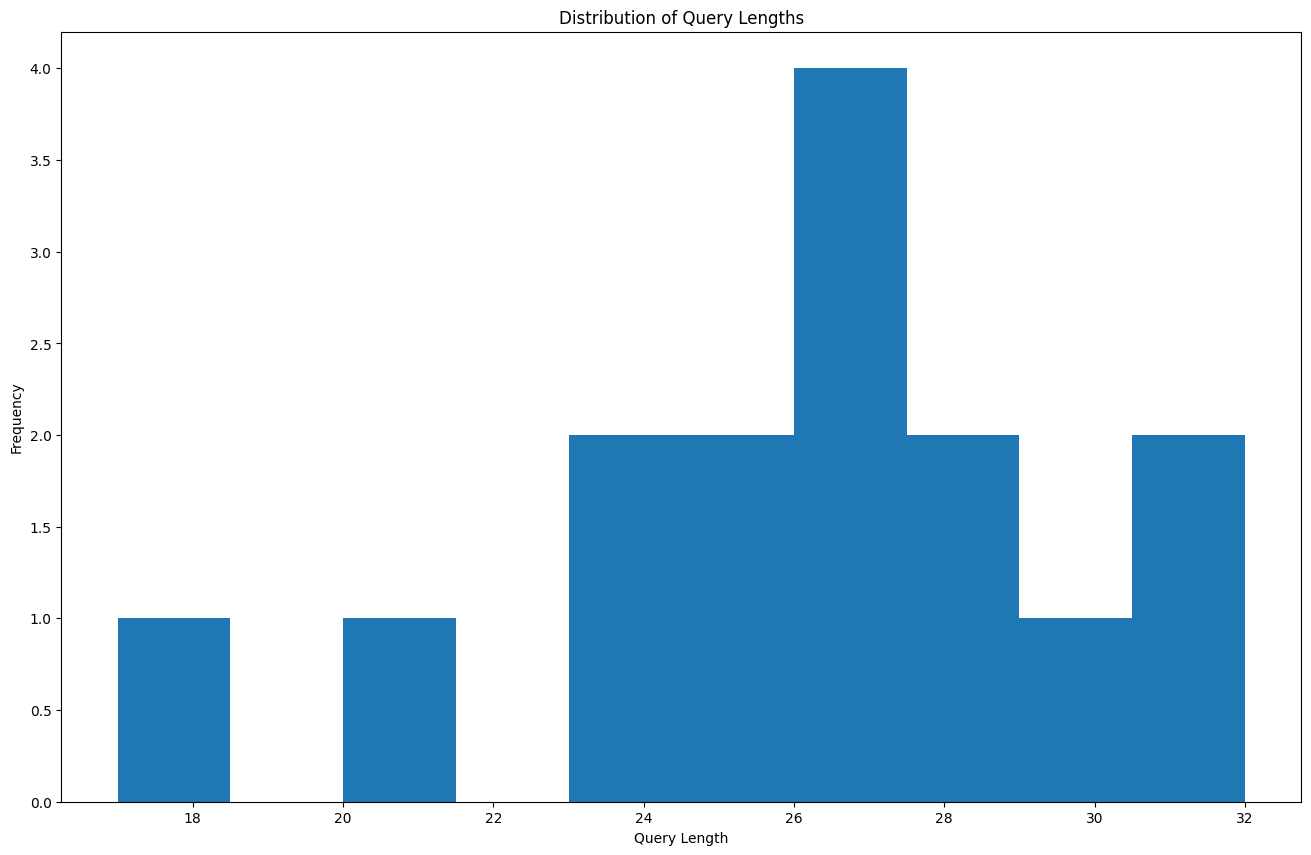

In [10]:
plt.figure(figsize=(16,10))
plt.hist(chatbot_df['query_length'])
plt.xlabel('Query Length')
plt.ylabel('Frequency')
plt.title('Distribution of Query Lengths')
plt.show()

In [11]:
chatbot_df['clean_query'] = chatbot_df['query'].str.lower()

In [12]:
def clean_text(text):
  text = re.sub(r'[^a-zA-Z\\s]','',text)
  return text

chatbot_df['clean_query'] = chatbot_df['clean_query'].apply(clean_text)

In [13]:
chatbot_df['clean_query'] = chatbot_df['clean_query'].apply(lambda x:re.sub(r'\\s+','',x))

In [14]:
chatbot_df['tokens'] = chatbot_df['clean_query'].apply(
    lambda x:x.split()
)

In [15]:
chatbot_df.head()

,query,response,intent,query_length,clean_query,tokens
0,What are your pricing plans?,"We offer Basic, Pro, and Enterprise pricing pl...",pricing,28,whatareyourpricingplans,[whatareyourpricingplans]
1,I forgot my password,You can reset your password using the forgot p...,password_reset,20,iforgotmypassword,[iforgotmypassword]
2,How do I contact support?,You can contact support at support@company.com,support,25,howdoicontactsupport,[howdoicontactsupport]
3,What is your refund policy?,Refunds are available within 30 days.,refund,27,whatisyourrefundpolicy,[whatisyourrefundpolicy]
4,My payment failed,Please retry payment or contact billing support.,payment_issue,17,mypaymentfailed,[mypaymentfailed]


In [16]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
  return[
      word for word in tokens if word not in stop_words
  ]

chatbot_df['filtered_tokens'] = chatbot_df['tokens'].apply(remove_stopwords)

In [17]:
stemmer = PorterStemmer()

def stem_words(tokens):
  return [
      stemmer.stem(word) for word in tokens
  ]

chatbot_df['stemmed_tokens'] = chatbot_df['filtered_tokens'].apply(stem_words)

In [20]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [21]:
lemmatizer = WordNetLemmatizer()

def lemmatize_words(tokens):

    return [

        lemmatizer.lemmatize(word)

        for word in tokens

    ]

chatbot_df['lemmatized_tokens'] = chatbot_df['filtered_tokens'].apply(

    lemmatize_words
)

In [23]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [24]:
sample_tokens = chatbot_df['tokens'].iloc[0]
nltk.pos_tag(sample_tokens)

[('whatareyourpricingplans', 'NNS')]

In [25]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 105.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [26]:
nlp = spacy.load('en_core_web_sm')

sample_text = "John wants to upgrade enterprise plan"

doc = nlp(sample_text)

for ent in doc.ents:
  print(ent.text, ent.label_)

John PERSON


In [27]:
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(
    chatbot_df['clean_query']
)

print(X_bow.shape)

(15, 15)


In [28]:
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(
    chatbot_df['clean_query']
)

In [30]:
print(X_tfidf.shape)

(15, 15)


In [31]:
sentences = chatbot_df['lemmatized_tokens'].tolist()

word2vec_model = Word2Vec(
    sentences,
    vector_size=50,
    window=3,
    min_count=1,
    workers=2
)

In [33]:
embedding_model = SentenceTransformer(

    'all-MiniLM-L6-v2'
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [34]:
query_embeddings = embedding_model.encode(

    chatbot_df['query'].tolist()
)

In [35]:
def retrieve_response(user_query):

    user_embedding = embedding_model.encode([user_query])

    similarities = cosine_similarity(

        user_embedding,

        query_embeddings
    )

    best_match_index = similarities.argmax()

    return chatbot_df.iloc[best_match_index]['response']

In [36]:
query = "How can I change my password?"

response = retrieve_response(query)

print(response)

You can reset your password using the forgot password page.


In [37]:
sentiment_pipeline = pipeline(

    "sentiment-analysis"
)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [38]:
sentiment_pipeline(

    "I am very frustrated with your service"
)

[{'label': 'NEGATIVE', 'score': 0.9996931552886963}]

In [39]:
chat_generator = pipeline(

    "text-generation",

    model="gpt2"
)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [40]:
prompt = """

Customer: My payment failed.

Support Agent:

"""

response = chat_generator(

    prompt,

    max_length=100,

    temperature=0.7
)

print(response[0]['generated_text'])

Passing `generation_config` together with generation-related arguments=({'temperature', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




Customer: My payment failed.

Support Agent:


No.

Solution: Send the payment to the correct billing address.


Answer:


Cancel the invoice or send the bill to:


Customer: My payment failed.

Support Agent:

No.

Solution: Send the payment to the correct billing address.


Answer:


Cancel the invoice or send the bill to:


Customer: My payment failed.

Support Agent:

No.

Solution: Send the payment to the correct billing address.


Answer:


Cancel the invoice or send the bill to:


Customer: My payment failed.

Support Agent:

No.

Solution: Send the payment to the correct billing address.


Answer:


Cancel the invoice or send the bill to:


Customer: My payment failed.

Support Agent:

No.

Solution: Send the payment to the correct billing address.


Answer:


Cancel the invoice or send the bill to:


Customer: My payment failed.

Support Agent:

No.

Solution: Send the payment to the correct billing address.


Answer:


Cancel the invoice


In [41]:
def build_prompt(user_query):

    return f"""

You are a professional enterprise AI assistant.

Customer Query:
{user_query}

Professional Response:

"""

In [42]:
conversation_history = []

def chatbot(user_query):

    conversation_history.append(user_query)

    retrieved = retrieve_response(user_query)

    return retrieved

In [43]:
print(chatbot("I forgot my password"))

print(chatbot("Can you help me reset it?"))

You can reset your password using the forgot password page.
Go to settings and click reset account.
